# Настройка окружения

## Install

In [ ]:
!pip install \
    bitsandbytes==0.46.0 \
    transformers==4.52.4 \
    accelerate==1.8.1 \
    datasets==3.6.0 \
    sentence-transformers==4.1.0 \
    chromadb==1.0.13 \
    flashrank \
    langchain==0.3.26 \
    langchain-community==0.3.26 \
    langchain-huggingface \
    tqdm==4.67.1 \
    ragas==0.1.9 \
    openai \
    langchain-groq


## Import




In [40]:
import torch
import transformers
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import os
from tqdm import tqdm


#------------------------------------------
#--------ЗАГРУЗКА ДАННЫХ И СПЛИТТЕР--------
#------------------------------------------

from datasets import load_dataset
from langchain_core.documents import Document # Updated import path
from langchain_text_splitters import RecursiveCharacterTextSplitter

#------------------------------------------
#--------------ВЕКТОРНАЯ БАЗА--------------
#------------------------------------------

from pathlib import Path
from langchain_community.document_loaders import TextLoader  # загружает текстовые файлы и превращает их в объекты Document для LangChain.
from langchain_huggingface import HuggingFaceEmbeddings  # оборачивает модели из HuggingFace для получения эмбеддингов текста.
from langchain_community.vectorstores import Chroma  # векторное хранилище Chroma: сохраняет и ищет эмбеддинги.

#------------------------------------------
#----------------RERANKER------------------
#------------------------------------------

from langchain.retrievers import ContextualCompressionRetriever
from langchain_community.document_compressors import FlashrankRerank

#------------------------------------------
#--------------КВАНТИЗАЦИЯ-----------------
#------------------------------------------

import bitsandbytes as bnb
from torch import cuda, bfloat16
from transformers import (AutoTokenizer,
                          BitsAndBytesConfig,
                          pipeline)

#------------------------------------------
#----------цепочка RetrievalQA-------------
#------------------------------------------

from langchain_huggingface import HuggingFacePipeline  # использует HuggingFace Transformers pipeline как LLM-модуль в LangChain.
from langchain.chains import RetrievalQA  # готовая цепочка «поиск + генерация ответа» (Retrieval-augmented QA).
from langchain import PromptTemplate

#------------------------------------------
#-------------ВАЛИДАЦИЯ RAG----------------
#------------------------------------------

from ragas import evaluate
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_recall,
    context_precision,
    answer_correctness
)
from ragas.embeddings import LangchainEmbeddingsWrapper
from datasets import Dataset, load_from_disk

#------------------------------------------
#-----------Работа с Groq Cloud------------
#------------------------------------------

from google.colab import userdata
from langchain_groq import ChatGroq
from ragas.llms import LangchainLLMWrapper


from tqdm import tqdm

# torchvision.disable_beta_transforms_warning()
DEVICE = f"cuda:{cuda.current_device()}" if cuda.is_available() else "cpu"

In [114]:
#Проверка версий
import importlib
import sys

packages = [
    "torch",
    "transformers",
    "bitsandbytes",
    "langchain",
    "langchain_core",
    "langchain_community",
    "chromadb",
    "datasets",
    "ragas",
    "openai",
    "langchain_groq"
]

for pkg in packages:
    try:
        module = importlib.import_module(pkg)
        version = getattr(module, "__version__", "⛔ нет атрибута __version__")
        print(f"{pkg:25s} → {version}")
    except ModuleNotFoundError:
        print(f"{pkg:25s} → ❌ не установлен")

torch                     → 2.8.0+cu126
transformers              → 4.52.4
bitsandbytes              → 0.46.0
langchain                 → 0.3.26
langchain_core            → 0.3.79
langchain_community       → 0.3.26
chromadb                  → 1.0.13
datasets                  → 3.6.0
ragas                     → 0.1.9
openai                    → 1.109.1
langchain_groq            → 0.3.8


# Анализ датасета

In [ ]:
qa_ds = load_dataset("rag-datasets/rag-mini-wikipedia", "question-answer", split = 'test')
corpus = load_dataset("rag-datasets/rag-mini-wikipedia", "text-corpus", split = 'passages')

tokenizer_retriever = AutoTokenizer.from_pretrained("sentence-transformers/all-mpnet-base-v2")

In [ ]:
print(f"Размер корпуса до очистки: {len(corpus)}")

seen_passages = set()

def is_valid_passage(example):
    passage_text = example["passage"].strip()

    # фильтрация по длине
    if len(passage_text) <= 45:
        return False

    # фильтрация по уникальности
    if passage_text not in seen_passages:
        seen_passages.add(passage_text)
        return True
    return False

# num_proc=1 — иначе seen_passages не будет общим между процессами
corpus = corpus.filter(is_valid_passage, num_proc=1)
print(f"Размер корпуса после очистки: {len(corpus)}")

    Размер корпуса до очистки: 3200
    Размер корпуса после очистки: 2892

In [9]:
qa_ds

Dataset({
    features: ['question', 'answer', 'id'],
    num_rows: 918
})

In [10]:
qa_ds[0]

{'question': 'Was Abraham Lincoln the sixteenth President of the United States?',
 'answer': 'yes',
 'id': 0}

In [11]:
corpus

Dataset({
    features: ['passage', 'id'],
    num_rows: 2892
})

In [12]:
corpus[0]

{'passage': 'Uruguay (official full name in  ; pron.  , Eastern Republic of  Uruguay) is a country located in the southeastern part of South America.  It is home to 3.3 million people, of which 1.7 million live in the capital Montevideo and its metropolitan area.',
 'id': 0}

In [13]:
def token_hist(lengths):
    plt.style.use("seaborn-v0_8-whitegrid")
    plt.figure(figsize=(10, 6))
    sns.histplot(lengths, bins=30, kde=True, color="cornflowerblue", edgecolor="black", alpha=0.8)

    plt.title("Распределение отрывков по длине (в токенах)", fontsize=18, pad=15)
    plt.xlabel("Количество токенов", fontsize=14)
    plt.ylabel("Частота", fontsize=14)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.grid(visible=True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

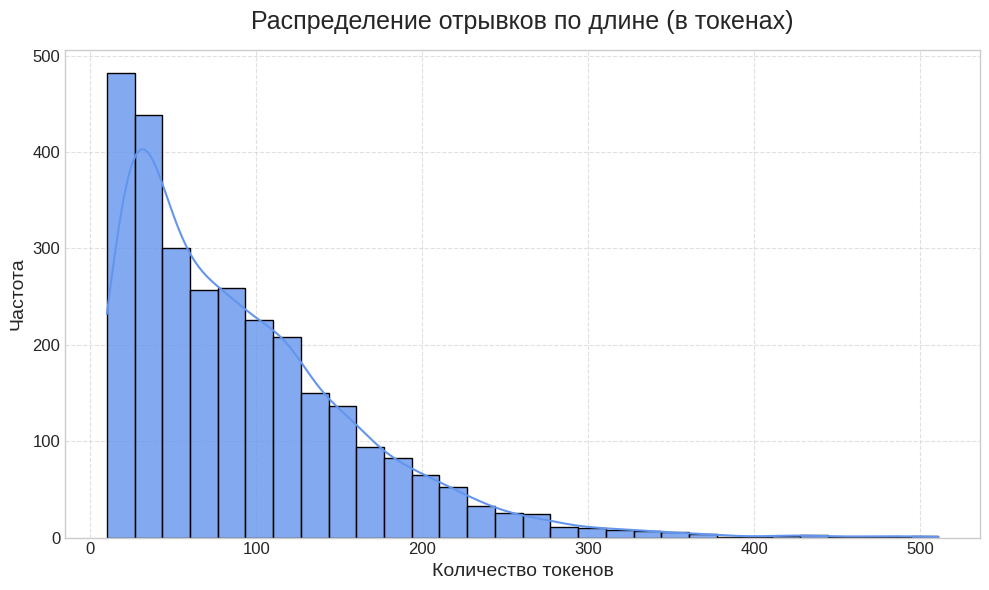

In [14]:
lengths_before_chunking = []
for doc in corpus:
    tokens = tokenizer_retriever.encode(doc['passage'])
    lengths_before_chunking.append(len(tokens))

token_hist(lengths_before_chunking)

## Деление на фрагменты

In [15]:
# Пороговое значение в токенах.
TOKEN_THRESHOLD = 400
overlap = 50
chunk_size = 200
# Инициализируем сплиттер для длинных документов (Длиннее порога)
text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
    tokenizer=tokenizer_retriever,
    chunk_size = chunk_size,
    chunk_overlap = overlap,         # Перекрытие для сохранения контекста
    strip_whitespace=True
)

splitted_docs = []

for doc_data in tqdm(corpus):
    doc_id = doc_data['id']
    text = doc_data['passage']
    token_count = len(tokenizer_retriever.encode(text))

    if token_count <= TOKEN_THRESHOLD:  # Документ короткий - не дробим
        new_doc = Document(
            page_content=text,
            metadata={"original_doc_id": doc_id, "source_type": "full_document"}
        )
        splitted_docs.append(new_doc)

    else: # Документ длинный - дробим
        chunks = text_splitter.split_text(text)
        for i, chunk_text in enumerate(chunks):
            new_chunk_doc = Document(
                page_content=chunk_text,
                metadata={
                    "original_doc_id": doc_id,
                    "chunk_num": i,
                    "source_type": "chunked_document"
                }
            )
            splitted_docs.append(new_chunk_doc)

100%|██████████| 2892/2892 [00:01<00:00, 1840.05it/s]


Всего чанков : 2913
Максимально токенов в чанке : 395


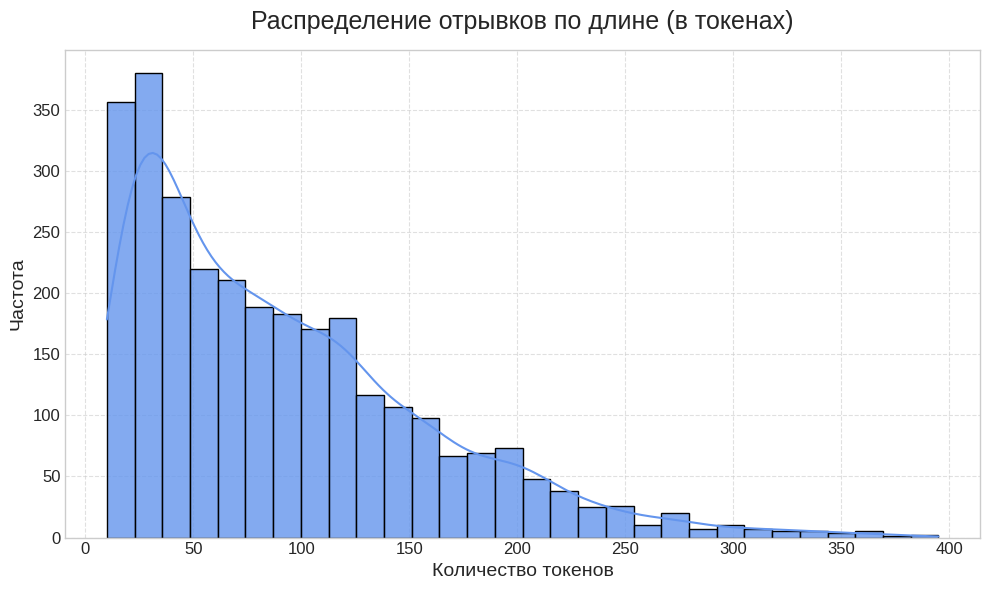

In [16]:
lengths = [len(tokenizer_retriever.encode(doc.page_content)) for doc in splitted_docs]
print(f'Всего чанков : {len(lengths)}')
print(f'Максимально токенов в чанке : {max(lengths)}')
token_hist(lengths)

# Retriever

## Создание векторной базы

In [ ]:
embedding = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-mpnet-base-v2", #модель считающая эмбеддинги фрагментов
    model_kwargs={"device": "cuda"},
)

#!!! Если запускать нексолько раз, не меняя папку, то документы начнут перезаписываться и дублироваться!
vectordb = Chroma.from_documents(
    documents=splitted_docs,
    embedding=embedding,
    persist_directory = "chroma_rag_wiki_2"  # папка для хранения векторной базы
)
vectordb.persist()  #записывает всё в папку

## Reranker

In [18]:
compressor = FlashrankRerank(top_n=2, model="ms-marco-MiniLM-L-12-v2")
base_retriever = vectordb.as_retriever(search_kwargs={"k": 10})

compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=base_retriever
)

ms-marco-MiniLM-L-12-v2.zip: 100%|██████████| 21.6M/21.6M [00:00<00:00, 168MiB/s]


# Generator

## Квантизация

In [ ]:
# Конфигурация квантования
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                          # включаем 4-битное квантование
    bnb_4bit_quant_type="nf4",                  # тип квантования NF4
    bnb_4bit_use_double_quant=True,             # двойное квантование для уменьшения объёма
    bnb_4bit_compute_dtype=torch.float16        # вычисления в float16
)

model = transformers.AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen3-8B",
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,  # передаём явно тип
    trust_remote_code=True      # может понадобиться для Qwen
)

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-8B", use_fast=True)

In [20]:
llm_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    torch_dtype=torch.float16,
    device_map="auto",
)

Device set to use cuda:0


In [21]:
llm_pipeline('who is the president of USA? I need only name',
             max_new_tokens=50, temperature=0.7, top_p=0.9)

[{'generated_text': "who is the president of USA? I need only name, no title.\nThe name of the current President of the United States is Joe Biden. However, please note that this information may be outdated, and it's always best to verify with the most recent sources. As of my knowledge cutoff in October "}]

# Сборка цепочки RetrievalQA

## Prompt

In [22]:
prompt_qwen = """You are a helpful and precise assistant. Your task is to answer the question based strictly on the provided context.
Follow these steps:
1. Carefully read the context and the question.
2. Inside the <thinking> tags, write down your step-by-step reasoning. First, extract the key facts from the context that are relevant to the question. Second, formulate an answer based ONLY on these facts.
3. After your reasoning, provide a final, short answer inside the <answer> tags. Very short answer!
4. If the answer is not present in the context, write "I don't know" in the answer tags and explain why in the thinking tags.

<context>
{context}
</context>

<question>
{question}
</question>

<thinking>
"""

In [23]:
# Шаблон запроса с явной инструкцией
custom_prompt = PromptTemplate(
    input_variables=["context", "question"],
    template = prompt_qwen
)

## Pipeline

In [24]:
llm = HuggingFacePipeline(
    pipeline=llm_pipeline,
    model_kwargs={
        "max_new_tokens": 200,
        #"temperature": 0.1,
        "do_sample": False,   #отключает сэмплирование
        "stop": ["</answer>"]
    }
)


qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=compression_retriever,
    return_source_documents=True,
    chain_type_kwargs={"prompt": custom_prompt}
)

In [25]:
#question = "Who is most noted for his contributions to the theory of molarity and molecular weight?"
question = "What trail did Lincoln use a Farmers' Almanac in?"

response = qa_chain.invoke(question)

print("Инструкция:\n", response["result"])
# print('\n\nИспользуемые тексты:\n')
# for doc in response["source_documents"]:
#     print('Document:')
#     print(doc.page_content[:150], "…", end="\n\n\n")

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Инструкция:
 You are a helpful and precise assistant. Your task is to answer the question based strictly on the provided context.
Follow these steps:
1. Carefully read the context and the question.
2. Inside the <thinking> tags, write down your step-by-step reasoning. First, extract the key facts from the context that are relevant to the question. Second, formulate an answer based ONLY on these facts.
3. After your reasoning, provide a final, short answer inside the <answer> tags. Very short answer!
4. If the answer is not present in the context, write "I don't know" in the answer tags and explain why in the thinking tags.

<context>
Possibly the most notable criminal trial of Lincoln's career as a lawyer came in 1858, when he defended William "Duff" Armstrong, who has been charged with murder. The case became famous for Lincoln's use of judicial notice--a rare tactic at that time--to show that an eyewitness had lied on the stand. After the witness testified to having seen the crime by

In [26]:
def extract_answer(text):
    pattern = r'<answer>.*?<answer>(.*?)</answer>'
    match_ = re.search(pattern, text, re.DOTALL)
    if match_:
        return match_.group(1).strip()
    return None

In [27]:
extract_answer(response["result"])

'The trial of William "Duff" Armstrong.'

# Валидация

## Подготовка датасета для ragas

In [30]:
# Готовим данные для оценки
EVAL_SAMPLES = 100
eval_dataset = qa_ds.shuffle(seed=42).select(range(EVAL_SAMPLES))

ragas_data = {
    "question": [],
    "answer": [],      # Сгенерированный ответ
    "contexts": [],    # Найденные контексты
    "ground_truth": [] # Эталонный ответ из датасета
}

for item in tqdm(eval_dataset):
    response = qa_chain.invoke(item['question'])

    ragas_data["question"].append(item['question'])
    ragas_data["answer"].append(extract_answer(response['result']))
    ragas_data["contexts"].append([doc.page_content for doc in response['source_documents']])
    ragas_data["ground_truth"].append(item['answer'])

ragas_dataset = Dataset.from_dict(ragas_data)

100%|██████████| 100/100 [41:29<00:00, 24.90s/it]


## Сохранение и загрузка датасета
Необходимо для промежуточных шагов

In [31]:
dir_path = '/content/drive/MyDrive/'

In [32]:
ragas_dataset.save_to_disk(dir_path + "ragas_dataset")

Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]

In [33]:
ragas_dataset = load_from_disk(dir_path + "ragas_dataset")
print(ragas_dataset)

Dataset({
    features: ['question', 'answer', 'contexts', 'ground_truth'],
    num_rows: 100
})


## Определение LLM для валидации

In [47]:
groq_llm = ChatGroq(
    api_key=userdata.get("groq2"),
    model="meta-llama/llama-4-scout-17b-16e-instruct",  # or "mixtral-8x7b-32768"
    temperature=0.1,
    max_tokens= 1024,
    max_retries = 5,              # Количество повторных попыток (по умолчанию 2)
    request_timeout = 60,         #максимальное время ожидания ответа от сервера.
)

ragas_llm = LangchainLLMWrapper(groq_llm)

## Оценка

In [48]:
embedding = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-mpnet-base-v2", #модель считающая эмбеддинги фрагментов
    model_kwargs={"device": "cuda"},
)

ragas_embeddings = LangchainEmbeddingsWrapper(embedding)

In [ ]:
result = evaluate(
    ragas_dataset.select(range(30)),
    metrics=[

        context_precision, # Насколько контекст релевантен? (Оценка ретривера)
        context_recall,    # Вся ли нужная информация есть в контексте? (Оценка ретривера)
        answer_relevancy,  # Отвечает ли модель на тот вопрос? (Оценка генератора)
        answer_correctness
        #faithfulness,      # Не галлюцинирует ли модель? (Оценка генератора) - не подходит для данного датасета
    ],

    llm=ragas_llm,
    embeddings=ragas_embeddings, # Модель, считающая эмбеддинги запросов и чанков
    raise_exceptions=False,      #чтобы не прерывалась при одной ошибке

)

print("\n--- RAGAs Evaluation Results ---")
print(result)

In [55]:
df = result.to_pandas()
df.to_csv(dir_path + "ragas_results.csv", index=False)

## Визуализация результатов

In [108]:
df = df.dropna()
metrics = ['context_precision', 'context_recall', 'answer_relevancy', 'answer_correctness']
desc = df[metrics].describe().loc[['mean', 'std', '25%', '50%', '75%']].round(3)

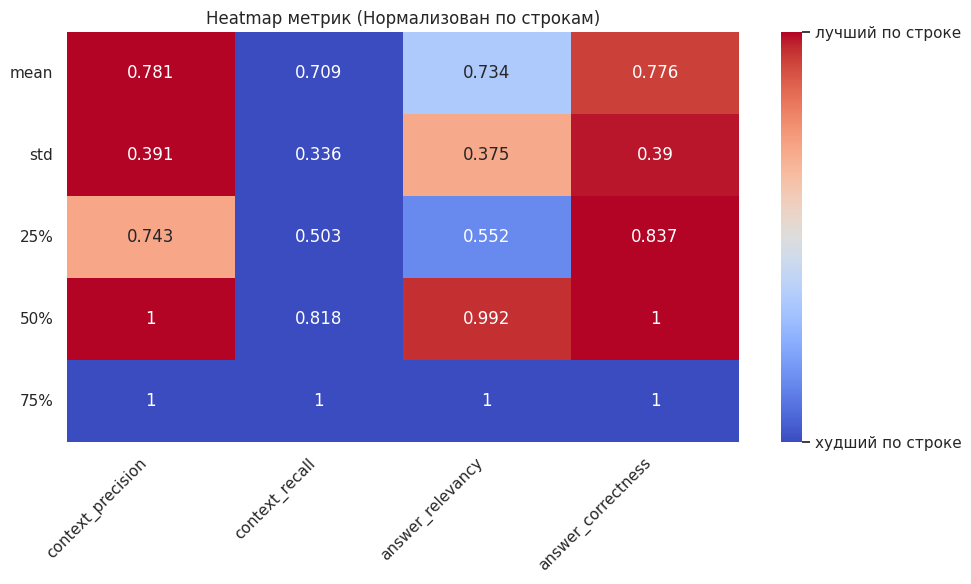

In [109]:
desc_min = desc.min(axis=1).values[:, np.newaxis]
desc_max = desc.max(axis=1).values[:, np.newaxis]
normalized = (desc  - desc_min) / ((desc_max - desc_min) + 1e-10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(normalized, annot=desc.round(3), fmt='g', cmap='coolwarm', ax=ax, cbar=True)

cbar = ax.collections[0].colorbar
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['худший по строке', 'лучший по строке'])

ax.set_title('Heatmap метрик (Нормализован по строкам)')
ax.set_yticklabels(desc.index, rotation=0)
ax.set_xticklabels(metrics, rotation=45, ha='right')

plt.tight_layout()
plt.show()

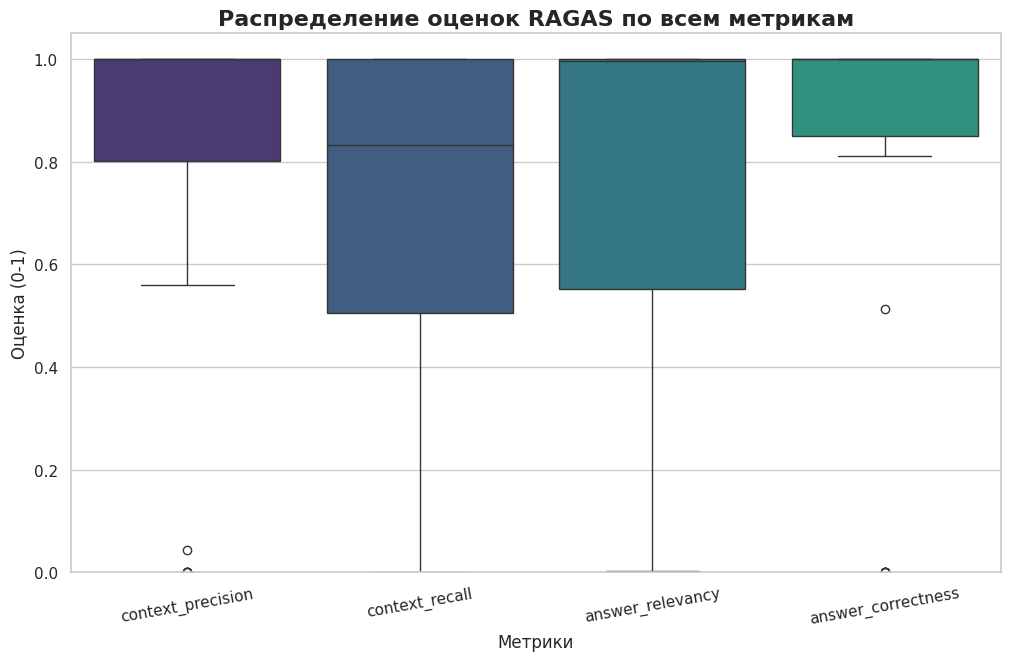

In [58]:
sns.set_theme(style="whitegrid", palette="viridis")
plt.figure(figsize=(12, 7))
sns.boxplot(data=df[metrics])
plt.title('Распределение оценок RAGAS по всем метрикам', fontsize=16, fontweight='bold')
plt.ylabel('Оценка (0-1)', fontsize=12)
plt.xlabel('Метрики', fontsize=12)
plt.ylim(0, 1.05)
plt.xticks(rotation=10)
plt.show()

# Выводы

RAG-система работает хорошо и уверенно в большинстве случаев, но неустойчива на части запросов: retriever иногда теряет часть информации (низкий recall), что снижает корректность ответов.